# Fake News Detection

Classifies news articles as **REAL** or **FAKE** and compares two approaches:

1. **Naive Bayes** on TF-IDF features (statistical baseline)
2. **Logistic Regression** on averaged **Word2Vec** embeddings

**Dataset:** [Fake and Real News Dataset](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset) on Kaggle. Download it and put `True.csv` and `Fake.csv` in a `data/` folder next to this notebook.

Running on Google Colab? Upload `True.csv` and `Fake.csv` into a `data/` folder using the file panel on the left before running.

In [1]:
import re

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from gensim.models import Word2Vec
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score, recall_score)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

for resource in ["stopwords", "punkt", "punkt_tab", "wordnet"]:
    nltk.download(resource, quiet=True)

## 1. Load and combine the data

In [2]:
DATA_DIR = "data"
true_news = pd.read_csv(f"{DATA_DIR}/True.csv")
fake_news = pd.read_csv(f"{DATA_DIR}/Fake.csv")

true_news["label"] = "REAL"
fake_news["label"] = "FAKE"

# Combine and shuffle
data = pd.concat([true_news, fake_news], ignore_index=True)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)
data["text"] = data["text"].fillna("")
data.head()

,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",FAKE
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",FAKE
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",FAKE
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",REAL
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",FAKE


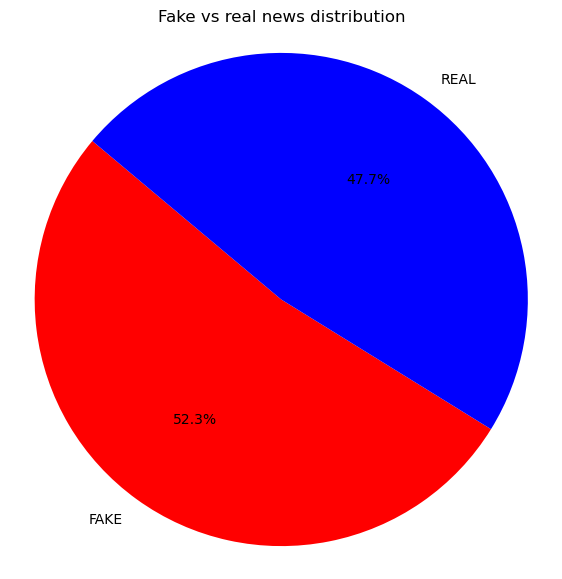

In [3]:
label_counts = data["label"].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(label_counts, labels=label_counts.index, autopct="%1.1f%%", startangle=140, colors=["red", "blue"])
plt.title("Fake vs real news distribution")
plt.axis("equal")
plt.show()

## 2. Preprocessing

Lowercase, strip punctuation and numbers, tokenize, remove stop words, lemmatize.

In [4]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return [lemmatizer.lemmatize(word) for word in tokens]


data["tokens"] = data["text"].apply(preprocess_text)
print("Preprocessing complete. Sample tokens:")
data[["text", "tokens"]].head()

Preprocessing complete. Sample tokens:


,text,tokens
0,"Donald Trump s White House is in chaos, and th...","[donald, trump, white, house, chaos, trying, c..."
1,Now that Donald Trump is the presumptive GOP n...,"[donald, trump, presumptive, gop, nominee, tim..."
2,Mike Pence is a huge homophobe. He supports ex...,"[mike, penny, huge, homophobe, support, exgay,..."
3,SAN FRANCISCO (Reuters) - California Attorney ...,"[san, francisco, reuters, california, attorney..."
4,Twisted reasoning is all that comes from Pelos...,"[twisted, reasoning, come, pelosi, day, especi..."


In [5]:
data["text_length"] = data["text"].apply(len)
data.groupby("label")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
FAKE,23481.0,2547.396235,2532.884399,1.0,1433.0,2166.0,3032.0,51794.0
REAL,21417.0,2383.278517,1684.835730,1.0,914.0,2222.0,3237.0,29781.0


## 3. Train/test split and TF-IDF features

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    data["tokens"], data["label"], test_size=0.2, random_state=42
)

# Fit the vectorizer on the training data only, then transform both sets
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train.apply(" ".join))
X_test_tfidf = tfidf_vectorizer.transform(X_test.apply(" ".join))

print("Training TF-IDF matrix:", X_train_tfidf.shape)
print("Test TF-IDF matrix:    ", X_test_tfidf.shape)

Training TF-IDF matrix: (35918, 181500)
Test TF-IDF matrix:     (8980, 181500)


## 4. Baseline: Naive Bayes + TF-IDF

Accuracy: 0.94

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.95      0.93      0.94      4669
        REAL       0.93      0.95      0.94      4311

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980



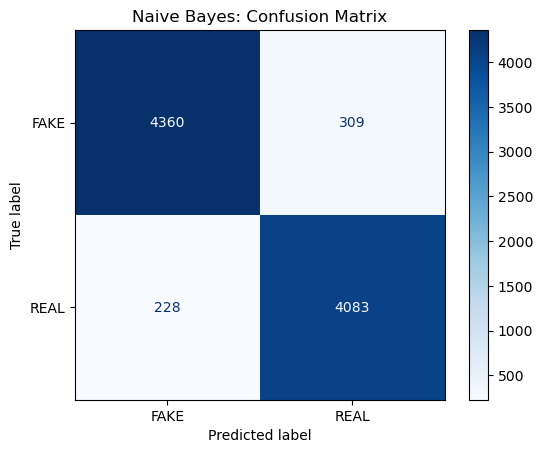

In [7]:
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_tfidf, y_train)
nb_pred = nb_classifier.predict(X_test_tfidf)

# REAL is treated as the positive class for precision, recall and F1
nb_scores = {
    "Accuracy": accuracy_score(y_test, nb_pred),
    "Precision": precision_score(y_test, nb_pred, pos_label="REAL"),
    "Recall": recall_score(y_test, nb_pred, pos_label="REAL"),
    "F1-Score": f1_score(y_test, nb_pred, pos_label="REAL"),
}
print(f"Accuracy: {nb_scores['Accuracy']:.2f}\n")
print("Classification Report:")
print(classification_report(y_test, nb_pred))

cm = confusion_matrix(y_test, nb_pred, labels=nb_classifier.classes_)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb_classifier.classes_).plot(cmap=plt.cm.Blues)
plt.title("Naive Bayes: Confusion Matrix")
plt.show()

## 5. Word2Vec embeddings + Logistic Regression

Word2Vec is trained on the training split only, so no information from the test articles reaches the model. Each article is represented by the average of its word vectors.

In [8]:
print("Training Word2Vec model...")
word2vec_model = Word2Vec(sentences=X_train, vector_size=100, window=5, min_count=1, workers=4, seed=42)


def generate_embeddings(token_lists, model):
    """Average the Word2Vec vectors of each document's words (zeros if none are known)."""
    embeddings = []
    for tokens in token_lists:
        vectors = [model.wv[word] for word in tokens if word in model.wv]
        embeddings.append(np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size))
    return np.array(embeddings)


X_train_emb = generate_embeddings(X_train, word2vec_model)
X_test_emb = generate_embeddings(X_test, word2vec_model)

Training Word2Vec model...


Training Logistic Regression model...


Accuracy: 0.97

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.98      0.97      0.97      4669
        REAL       0.96      0.98      0.97      4311

    accuracy                           0.97      8980
   macro avg       0.97      0.97      0.97      8980
weighted avg       0.97      0.97      0.97      8980



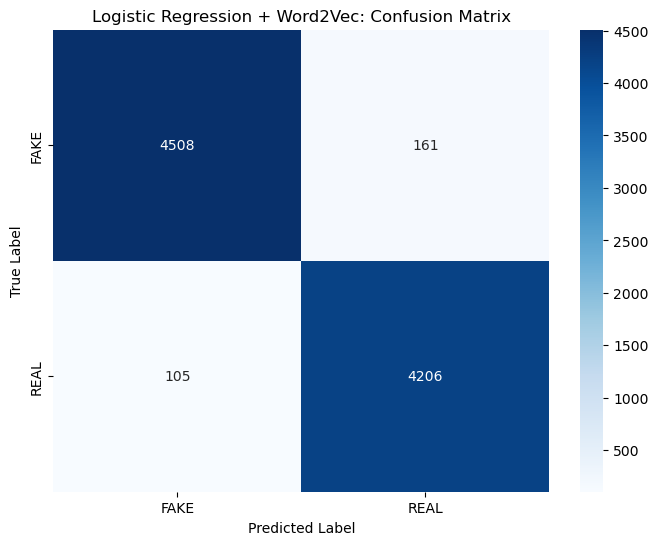

In [9]:
y_train_numeric = (y_train == "REAL").astype(int)
y_test_numeric = (y_test == "REAL").astype(int)

print("Training Logistic Regression model...")
logistic_regressor = LogisticRegression(max_iter=1000)
logistic_regressor.fit(X_train_emb, y_train_numeric)
lr_pred = logistic_regressor.predict(X_test_emb)

lr_scores = {
    "Accuracy": accuracy_score(y_test_numeric, lr_pred),
    "Precision": precision_score(y_test_numeric, lr_pred),
    "Recall": recall_score(y_test_numeric, lr_pred),
    "F1-Score": f1_score(y_test_numeric, lr_pred),
}
print(f"Accuracy: {lr_scores['Accuracy']:.2f}\n")
print("Classification Report:")
print(classification_report(y_test_numeric, lr_pred, target_names=["FAKE", "REAL"]))

conf_matrix = confusion_matrix(y_test_numeric, lr_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["FAKE", "REAL"], yticklabels=["FAKE", "REAL"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Logistic Regression + Word2Vec: Confusion Matrix")
plt.show()

## 6. Model comparison

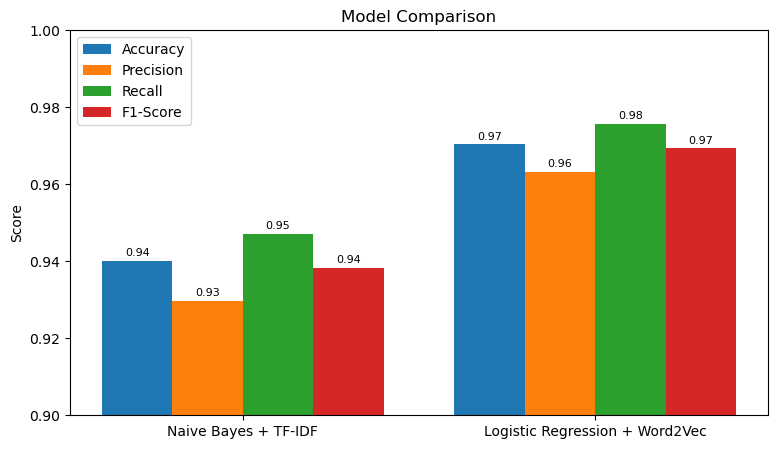

In [10]:
model_names = ["Naive Bayes + TF-IDF", "Logistic Regression + Word2Vec"]
metric_names = list(nb_scores)
x = np.arange(len(model_names))
width = 0.2

plt.figure(figsize=(9, 5))
for i, metric in enumerate(metric_names):
    values = [nb_scores[metric], lr_scores[metric]]
    bars = plt.bar(x + (i - 1.5) * width, values, width, label=metric)
    plt.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)

plt.xticks(x, model_names)
plt.ylabel("Score")
plt.title("Model Comparison")
plt.ylim(0.9, 1.0)
plt.legend(loc="upper left")
plt.show()

## Takeaways

- **Logistic Regression on Word2Vec embeddings** reaches about **97%** accuracy against about **94%** for **Naive Bayes on TF-IDF**, because averaged embeddings capture relationships between words that raw word frequencies miss.
- **Naive Bayes** is far simpler and quicker to train, so it is still a good baseline.